In [1]:
import sys
import os

# Add parent directory to path to access modules
sys.path.insert(0, os.path.abspath('..'))

import xarray as xr
import matplotlib.pyplot as plt
import torch
import pandas as pd
import seaborn as sns
import numpy as np
from mpl_toolkits.basemap import Basemap
import geopandas as gpd
from esda.moran import Moran
from eval.metrics import *
from eval.plot import *
import data.valid_crd as valid_crd
import yaml
import data.helper as helper
from matplotlib.colors import ListedColormap
import math
import scipy.stats as stats
# import statsmodels.api as sm
from collections import defaultdict
from scipy.stats import gaussian_kde

In [ ]:


test_period = [1990, 2014]
spatial_extent = ['05']



exps= ['4ff90755', 'a3780ca6', '6cde5f80', 'cac5a49c', '627e994f', '4eb36789'] #Spatial(05)Adam, LOCAspatio_tempConv1d, harmonic0, spatialCorrloss montone2-8, lr1e-3, livneh
testep = [60, 70, 70, 70, 90, 10]

base_dir = 'outputs/spatial_Adam_harmonic0/jobs_LOCAspatioTempConv1d'

save_path = f'{base_dir}/plots/Final_final_paper_nowghtdecay_5b/'
os.makedirs(save_path, exist_ok=True)

def load_model_run(run_id, test_period, epoch=None, base_dir=base_dir):

    run_path = helper.load_run_path(run_id, base_dir)

    flat_dir = os.path.join(run_path, f"{spatial_extent}")

    future_path = os.path.join(run_path, "ssp5_8_5_2075_2099")

    # Check which structure exists
    data_path = flat_dir
    config_path = os.path.join(run_path, 'train_config.yaml')

    x = torch.load(os.path.join(data_path, 'x.pt'), map_location='cpu', weights_only=True).squeeze(-1).numpy()
    x[x<0.254] = 0
    y = torch.load(os.path.join(data_path, 'y.pt'), map_location='cpu', weights_only=True).squeeze(-1).numpy()
    y[y<0.254] = 0
    time = torch.load(os.path.join(data_path, 'time.pt'), map_location='cpu', weights_only=False)

    xt = None
    if epoch is not None:
        xt_path = os.path.join(data_path, f'ep{epoch}', 'xt.pt')
        if os.path.exists(xt_path):
            xt = torch.load(xt_path, map_location='cpu', weights_only=False)
        else:
            print(run_id)
        xt[xt<0.254] = 0


    with open(config_path, 'r') as f:
        config = yaml.safe_load(f)

    return {
        'run_path': run_path,
        'x': x,
        'y': y,
        'time': time,
        'xt': xt,
        'config': config
    }

models = []
for i in range(len(exps)):
    model = load_model_run(exps[i], test_period, epoch=testep[i])
    models.append(model)

In [ ]:
valid_coords = []


for i in range(len(models)):
    
    cmip6_dir = models[i]['config']['cmip_dir']
    clim = models[i]['config']['clim']
    ref = models[i]['config']['ref']
    train_period = [models[i]['config']['train_start'], models[i]['config']['train_end']]
    future_period = [2015,2099]


    ds_sample = xr.open_dataset(f"{cmip6_dir}/{clim}/historical/precipitation/clipped_US.nc")

    shapefile_path = None if not  models[i]['config']['spatial_test']  else models[i]['config']['shapefile_filter_path']
    
    valid_coords.append(valid_crd.valid_lat_lon(ds_sample, var_name='pr', shapefile_path=shapefile_path, attrList=spatial_extent, attr='huc2'))

In [ ]:
## this block filters 'y' based on 'x' calender
counter = 0
for model in models:
    time = model['time']
    
    x_time_np = np.array([pd.Timestamp(str(t)) for t in time])
    x_time_np = np.array([pd.Timestamp(t).replace(hour=0, minute=0, second=0) for t in x_time_np], dtype='datetime64[D]')
    # Generate a daily time array following the standard Gregorian calendar
    y_time = pd.date_range(start=f"{test_period[0]}-01-01", end=f"{test_period[1]}-12-31", freq="D")

    # Convert to NumPy array for indexing and comparison
    y_time_np = y_time.to_numpy()

    # Find indices where observed time matches model time
    matched_indices = np.where(np.isin(y_time_np, x_time_np))[0]

    model['y'] = model['y'][matched_indices,:]
    model['x_time_np'] = x_time_np



    counter+=1







In [5]:
def find_nearest_indices(city_coords, valid_coords):
    nearest_indices = []
    nearest_coords = []

    for coord in city_coords:
        # Broadcasting subtraction
        dists = np.linalg.norm(valid_coords - coord, axis=1)
        idx = np.argmin(dists)
        nearest_indices.append(idx)
        nearest_coords.append(valid_coords[idx])

    return nearest_indices, np.array(nearest_coords)


interp_coords = []
ensemble_coords = valid_coords[2]
for coords in valid_coords:
    interp_coords.append(find_nearest_indices(ensemble_coords, coords))

In [ ]:
# Initialize climate indices manager
climate_indices = ClimateIndices()

thresholds = climate_indices.get_indices()
x_ensemble_indices = defaultdict(list)
y_ensemble_indices = defaultdict(list)
xt_ensemble_indices = defaultdict(list)


counter = 0
for model in models:
    target_idx = interp_coords[counter][0]
    for label, (threshold, comparison) in thresholds.items():
        if callable(threshold):  # If function, apply it to each dataset
            model[f"{label}_x"] = threshold(model["x_time_np"], model["x"])
            model[f"{label}_y"] = threshold(model["x_time_np"], model["y"])
            model[f"{label}_xt"] = threshold(model["x_time_np"], model["xt"])
       

            x_ensemble_indices[label].append(model[f"{label}_x"][:, target_idx])
            y_ensemble_indices[label].append(model[f"{label}_y"][:, target_idx])
            xt_ensemble_indices[label].append(model[f"{label}_xt"][:, target_idx])

    counter += 1


for label in x_ensemble_indices.keys():
    x_ensemble_indices[label] = np.concatenate(x_ensemble_indices[label], axis=1)
    y_ensemble_indices[label] = np.concatenate(y_ensemble_indices[label], axis=1)
    xt_ensemble_indices[label] = np.concatenate(xt_ensemble_indices[label], axis=1)




bias_dict = {}

for label, (threshold, comparison) in thresholds.items():
    if callable(threshold):
        xt_bias = compute_mean_bias_percentage(None, x_ensemble_indices[label], y_ensemble_indices[label], xt_ensemble_indices[label])

        bias_dict[label] = (xt_bias[0], xt_bias[1])

x_avg = np.nanmean([bias[0] for bias in bias_dict.values()], axis=0)
xt_avg = np.nanmean([bias[1] for bias in bias_dict.values()], axis=0)


bias_dict["Average"] = (x_avg, xt_avg)

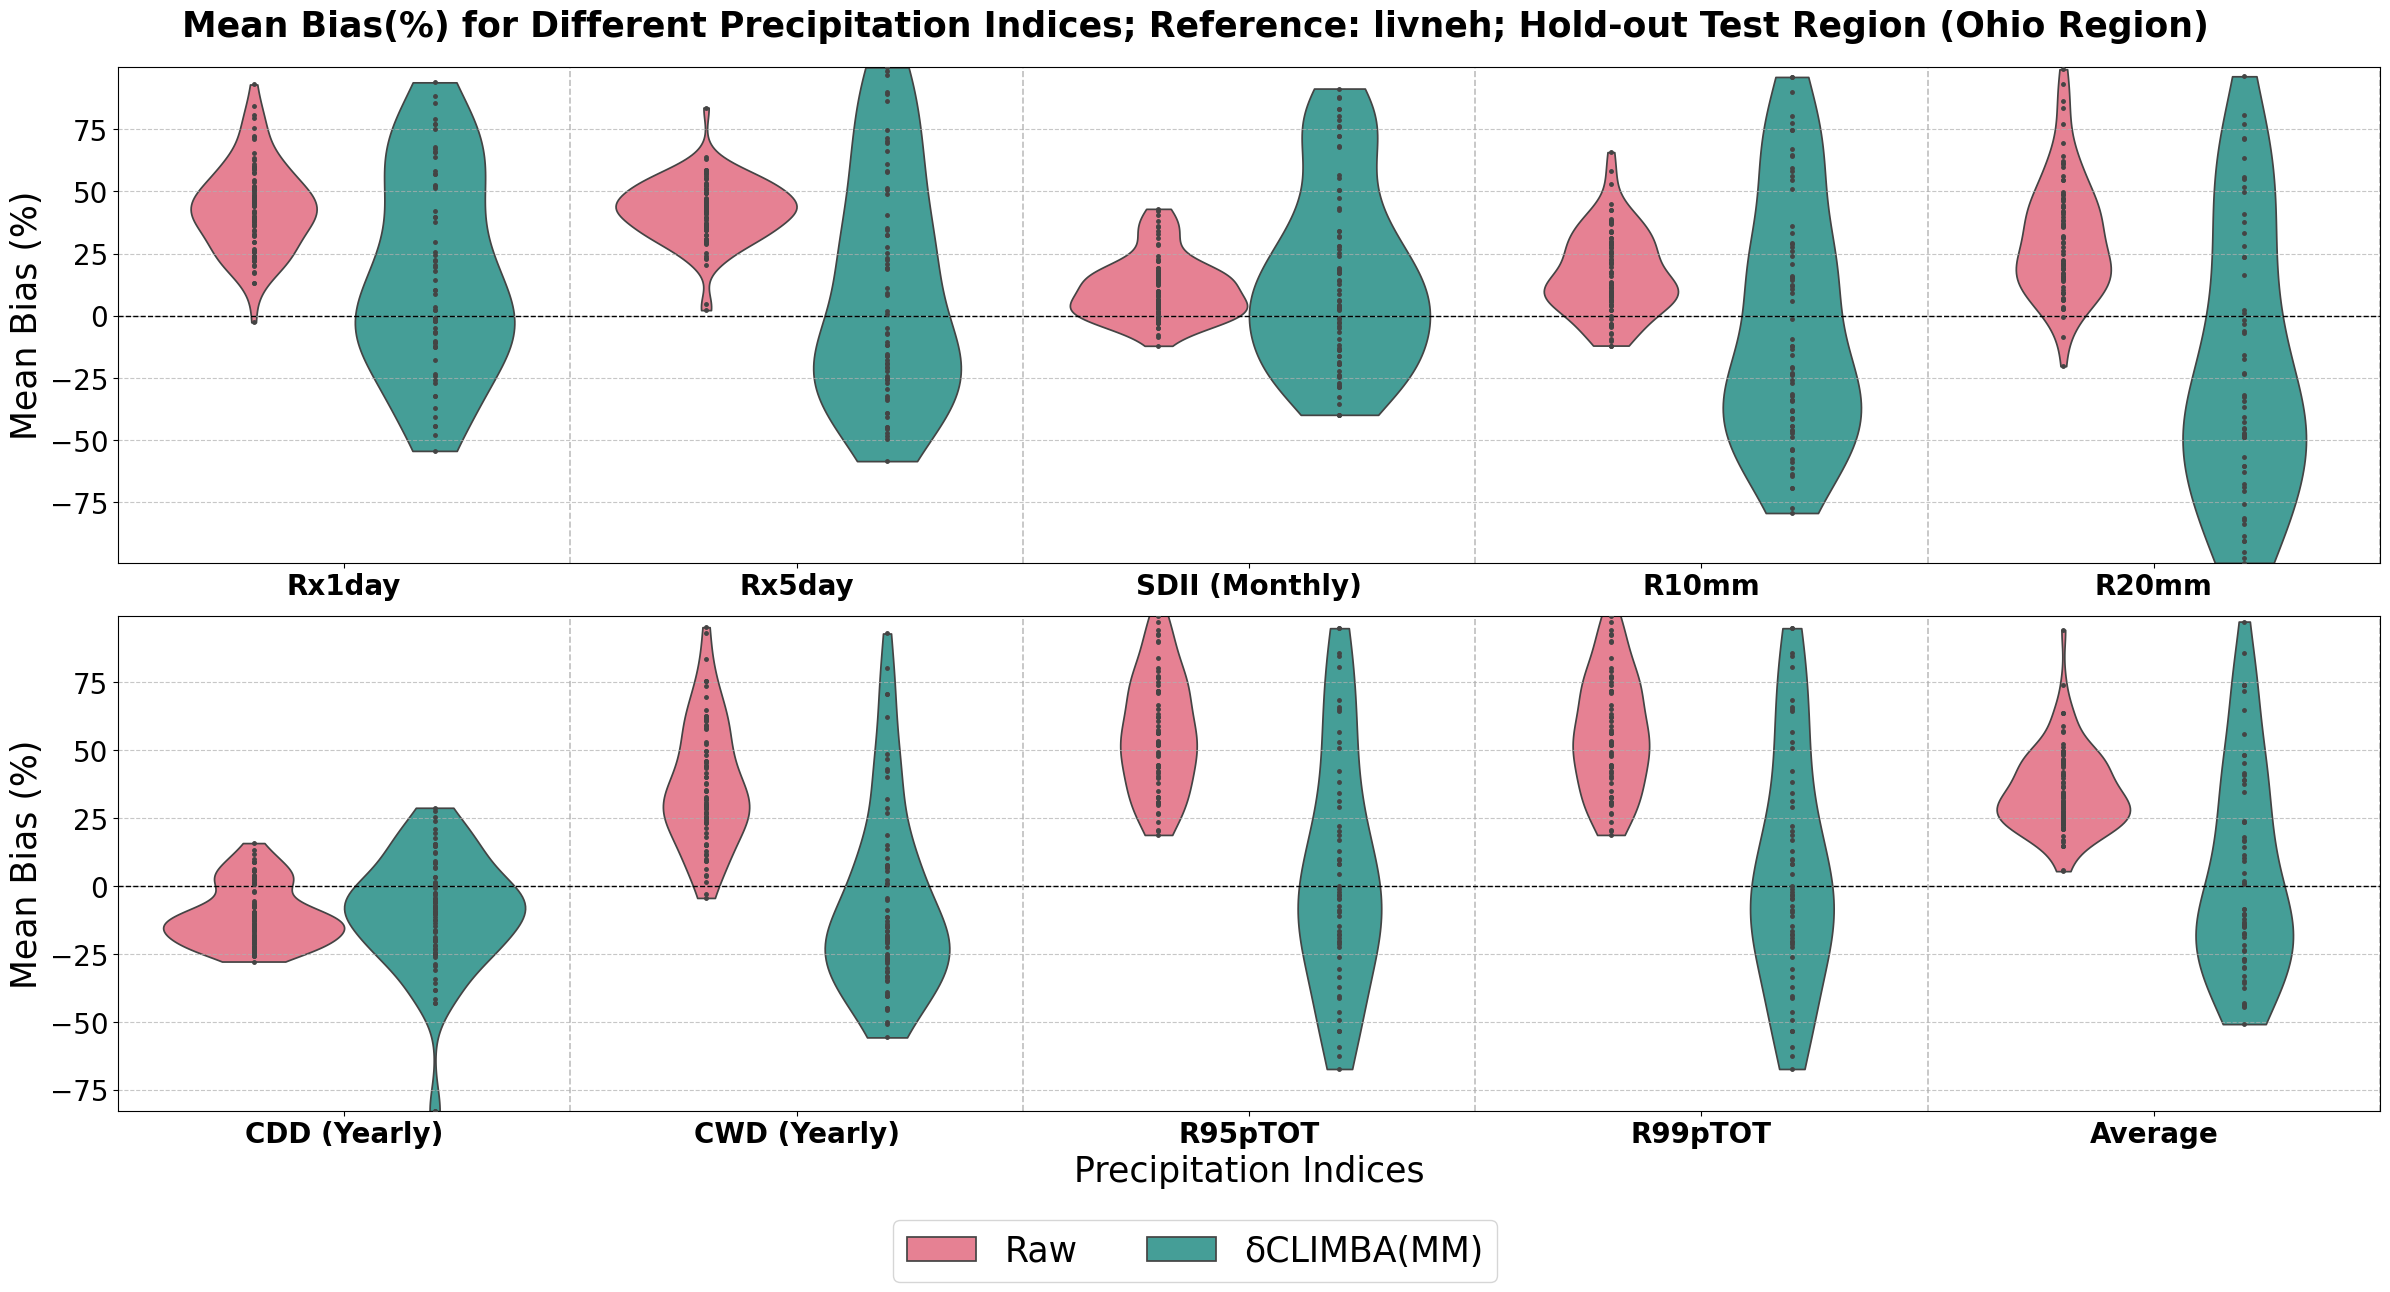

In [ ]:
keys = ['SDII (Monthly)','CDD (Yearly)', 'CWD (Yearly)', "Rx1day", "Rx5day", "R10mm",  "R20mm", "R95pTOT", "R99pTOT", 'Average']
d = dict(filter(lambda item: item[0] in keys , bias_dict.items()))

# Split keys into two groups for two rows
keys_list = list(d.keys())
d1 = dict(list(d.items())[:5])  # First 5 indices
d2 = dict(list(d.items())[5:])  # Remaining indices

# Create a 2x1 subplot figure (2 rows, 1 column)
fig, axes = plt.subplots(2, 1, figsize=(24, 12))

ref_label = models[0]['config']['ref']
method_names = ['δCLIMBA(MM)'] 

# Call the function for each row with different data
plot_violin_bias(axes[0], d1, "Bias(%)", "",  method_names=method_names, remove_outlier=True)
axes[0].legend().remove()  # Remove legend from top plot
axes[0].set_ylabel("Mean Bias (%)", fontsize=25)
axes[0].set_xlabel("")  # Remove x-axis label from row 1
axes[0].margins(y=0)

plot_violin_bias(axes[1], d2, "Bias(%)", "",  method_names=method_names, remove_outlier=True)
axes[1].legend().remove()  # Remove legend from bottom plot
axes[1].set_xlabel("Precipitation Indices", fontsize=25)
axes[1].set_ylabel("Mean Bias (%)", fontsize=25)
axes[1].margins(y=0)
# Set same tick font size for both rows
axes[0].tick_params(axis='x', labelsize=20)
axes[0].tick_params(axis='y', labelsize=20)
axes[1].tick_params(axis='x', labelsize=20)
axes[1].tick_params(axis='y', labelsize=20)

# Add single title at the top
fig.suptitle(f"Mean Bias(%) for Different Precipitation Indices; Reference: {ref_label}; Hold-out Test Region (Ohio Region)", fontsize=25, fontweight="bold", y=0.995)

# Place legend as one line at bottom center
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, fontsize=25, loc='lower center', bbox_to_anchor=(0.5, -0.08), ncol=len(handles), frameon=True)
def add_x_separators(ax, n_categories, color="gray", lw=1.2, ls="--", alpha=0.5):
    # Draw vertical lines between category groups
    for x in np.arange(0.5, n_categories - 0.5 + 1e-9, 1.0):
        ax.axvline(x=x, color=color, linewidth=lw, linestyle=ls, alpha=alpha, zorder=0)

# After plotting
add_x_separators(axes[0], len(d1))
add_x_separators(axes[1], len(d2))
plt.tight_layout()
plt.savefig(f'{save_path}/violin_Pindices.png')
plt.show()